# 03 — Molecular Feature Engineering

## Objective

Convert validated EGFR inhibitor structures into numerical molecular features suitable for machine-learning analysis.

Two types of molecular representations will be generated:

1. Physicochemical molecular descriptors
2. Morgan molecular fingerprints

These representations will later be used to train and compare machine-learning models for EGFR pIC50 prediction.

### Imports and paths

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski

In [3]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

input_path = (
    PROCESSED_DATA_DIR /
    "egfr_molecule_activity_with_smiles.csv"
)

In [4]:
df = pd.read_csv(input_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (10381, 8)


,molecule_chembl_id,median_ic50_nM,n_measurements,min_ic50_nM,max_ic50_nM,pIC50,canonical_smiles,valid_smiles
0,CHEMBL10,53000.0,2,10000.0,96000.0,4.275724,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,True
1,CHEMBL1009,2880.0,1,2880.0,2880.0,5.540608,N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O,True
2,CHEMBL101253,457.7,1,457.7,457.7,6.339419,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,True
3,CHEMBL1016,3276.9,1,3276.9,3276.9,5.484537,CCOc1nc2cccc(C(=O)O)c2n1Cc1ccc(-c2ccccc2-c2nnn...,True
4,CHEMBL101683,7300.0,1,7300.0,7300.0,5.136677,O=C(Nc1ccc(Cl)cc1)c1ccccc1NCc1ccncc1,True


### Convert SMILES into RDKit molecules

In [5]:
df["mol"] = df["canonical_smiles"].apply(Chem.MolFromSmiles)

print("RDKit molecules created:", df["mol"].notna().sum())
print("Failed conversions:", df["mol"].isna().sum())

RDKit molecules created: 10381
Failed conversions: 0


### Calculate basic molecular descriptors

In [6]:
def calculate_descriptors(mol):
    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "RingCount": Lipinski.RingCount(mol),
        "HeavyAtomCount": Lipinski.HeavyAtomCount(mol)
    }

In [7]:
descriptor_data = df["mol"].apply(calculate_descriptors)

descriptor_df = pd.DataFrame(
    descriptor_data.tolist(),
    index=df.index
)

descriptor_df.head()

,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,RingCount,HeavyAtomCount
0,377.444,4.6822,64.63,1,3,4,4,27
1,197.190,0.0522,103.78,4,4,3,1,14
2,346.821,5.0126,50.70,1,4,4,4,25
3,440.463,4.0286,118.81,2,6,7,5,33
4,337.810,4.5994,54.02,2,3,5,3,24


### Combine them with activity data

In [8]:
features_df = pd.concat(
    [
        df[
            [
                "molecule_chembl_id",
                "canonical_smiles",
                "pIC50"
            ]
        ],
        descriptor_df
    ],
    axis=1
)

print("Feature dataset shape:", features_df.shape)

features_df.head()

Feature dataset shape: (10381, 11)


,molecule_chembl_id,canonical_smiles,pIC50,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,RingCount,HeavyAtomCount
0,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,4.275724,377.444,4.6822,64.63,1,3,4,4,27
1,CHEMBL1009,N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O,5.540608,197.190,0.0522,103.78,4,4,3,1,14
2,CHEMBL101253,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,6.339419,346.821,5.0126,50.70,1,4,4,4,25
3,CHEMBL1016,CCOc1nc2cccc(C(=O)O)c2n1Cc1ccc(-c2ccccc2-c2nnn...,5.484537,440.463,4.0286,118.81,2,6,7,5,33
4,CHEMBL101683,O=C(Nc1ccc(Cl)cc1)c1ccccc1NCc1ccncc1,5.136677,337.810,4.5994,54.02,2,3,5,3,24


In [9]:
features_df.describe()

,pIC50,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,RingCount,HeavyAtomCount
count,10381.000000,10381.000000,10381.000000,10381.000000,10381.000000,10381.000000,10381.000000,10381.000000,10381.000000
mean,6.933809,484.321726,4.598976,96.220219,2.194105,6.757152,6.952317,4.457374,34.123399
std,1.305907,119.539421,1.424315,30.585424,1.187924,2.175684,3.202230,1.291382,8.565653
min,4.000000,110.112000,-5.994500,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,5.998266,404.474000,3.694000,76.960000,1.000000,5.000000,5.000000,4.000000,28.000000
50%,6.995679,482.979000,4.546340,96.370000,2.000000,7.000000,7.000000,4.000000,34.000000
75%,7.929962,555.683000,5.485700,111.720000,3.000000,8.000000,9.000000,5.000000,40.000000
max,11.000000,1425.805000,13.028900,530.870000,17.000000,19.000000,36.000000,12.000000,103.000000


In [10]:
features_df.isna().sum()

molecule_chembl_id    0
canonical_smiles      0
pIC50                 0
MolWt                 0
LogP                  0
TPSA                  0
HBD                   0
HBA                   0
RotatableBonds        0
RingCount             0
HeavyAtomCount        0
dtype: int64

## Morgan Molecular Fingerprints

Morgan fingerprints were generated to encode local molecular substructures as numerical features.

Each molecule was represented using a 2048-bit Morgan fingerprint with a radius of 2. These fingerprints provide a structure-based representation that complements the physicochemical molecular descriptors.

### Import the fingerprint generator

In [11]:
from rdkit.Chem import rdFingerprintGenerator

### Create the generator

In [12]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

### Generate fingerprints

In [13]:
fingerprints = [
    morgan_generator.GetFingerprint(mol)
    for mol in df["mol"]
]

print("Fingerprints generated:", len(fingerprints))
print("Fingerprint length:", fingerprints[0].GetNumBits())

Fingerprints generated: 10381
Fingerprint length: 2048


In [14]:
from rdkit import DataStructs

fingerprint_array = np.zeros(
    (len(fingerprints), 2048),
    dtype=np.uint8
)

for i, fp in enumerate(fingerprints):
    DataStructs.ConvertToNumpyArray(
        fp,
        fingerprint_array[i]
    )

print("Fingerprint matrix shape:", fingerprint_array.shape)

Fingerprint matrix shape: (10381, 2048)


### Inspect

In [15]:
print("First molecule:")
print(df.loc[0, "molecule_chembl_id"])

print("\nSMILES:")
print(df.loc[0, "canonical_smiles"])

print("\nNumber of active fingerprint bits:")
print(int(fingerprint_array[0].sum()))

First molecule:
CHEMBL10

SMILES:
C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc3)[nH]2)cc1

Number of active fingerprint bits:
40


## Save Molecular Features

The physicochemical descriptor dataset and Morgan fingerprint matrix were saved separately for downstream exploratory analysis and machine-learning model development.

In [16]:
descriptor_output = (
    PROCESSED_DATA_DIR /
    "egfr_molecular_descriptors.csv"
)

features_df.to_csv(
    descriptor_output,
    index=False
)

print(f"Descriptor dataset saved to:\n{descriptor_output}")

Descriptor dataset saved to:
/Users/gracescanlan/Desktop/egfr-ml-drug-discovery/data/processed/egfr_molecular_descriptors.csv


In [17]:
fingerprint_output = (
    PROCESSED_DATA_DIR /
    "egfr_morgan_fingerprints.npz"
)

np.savez_compressed(
    fingerprint_output,
    fingerprints=fingerprint_array,
    molecule_chembl_id=df["molecule_chembl_id"].values,
    pIC50=df["pIC50"].values
)

print(f"Fingerprint matrix saved to:\n{fingerprint_output}")

Fingerprint matrix saved to:
/Users/gracescanlan/Desktop/egfr-ml-drug-discovery/data/processed/egfr_morgan_fingerprints.npz


## EDA

### Correlations

In [18]:
descriptor_columns = [
    "MolWt",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount",
    "HeavyAtomCount"
]

correlations = (
    features_df[
        descriptor_columns + ["pIC50"]
    ]
    .corr()["pIC50"]
    .drop("pIC50")
    .sort_values(ascending=False)
)

correlations

HBA               0.258422
MolWt             0.243347
HeavyAtomCount    0.232474
RingCount         0.221966
LogP              0.201148
HBD               0.184981
RotatableBonds    0.184522
TPSA              0.090983
Name: pIC50, dtype: float64

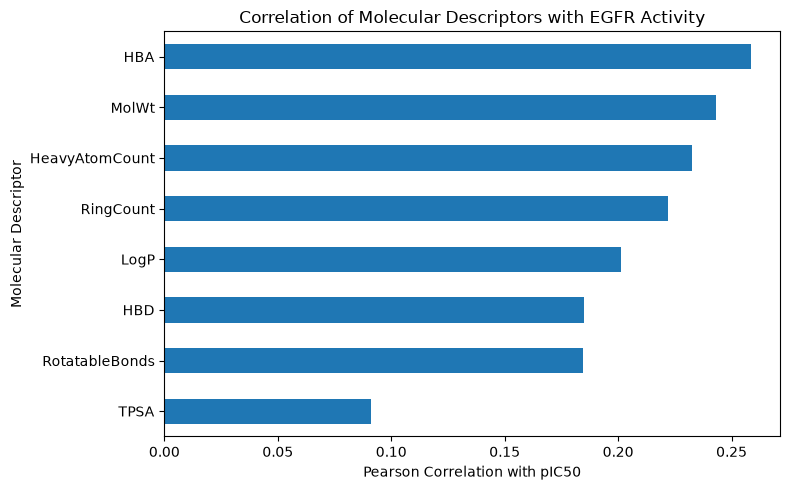

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

correlations.sort_values().plot(
    kind="barh"
)

plt.xlabel("Pearson Correlation with pIC50")
plt.ylabel("Molecular Descriptor")
plt.title("Correlation of Molecular Descriptors with EGFR Activity")

plt.tight_layout()
plt.show()

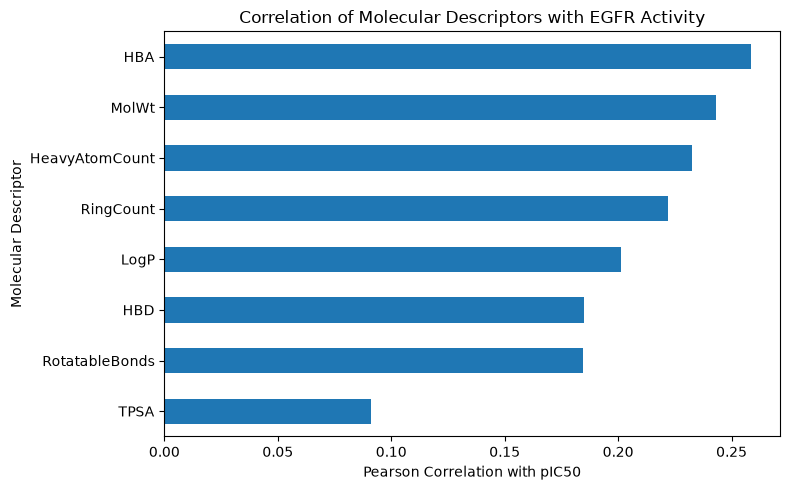

In [20]:
figure_path = (
    PROJECT_ROOT /
    "figures" /
    "descriptor_pic50_correlations.png"
)

plt.figure(figsize=(8, 5))

correlations.sort_values().plot(
    kind="barh"
)

plt.xlabel("Pearson Correlation with pIC50")
plt.ylabel("Molecular Descriptor")
plt.title("Correlation of Molecular Descriptors with EGFR Activity")

plt.tight_layout()
plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Relationships

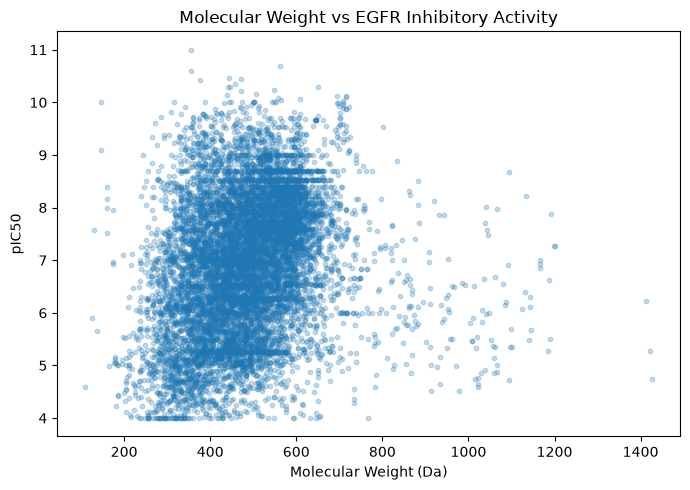

In [21]:
plt.figure(figsize=(7, 5))

plt.scatter(
    features_df["MolWt"],
    features_df["pIC50"],
    alpha=0.25,
    s=10
)

plt.xlabel("Molecular Weight (Da)")
plt.ylabel("pIC50")
plt.title("Molecular Weight vs EGFR Inhibitory Activity")

plt.tight_layout()
plt.show()

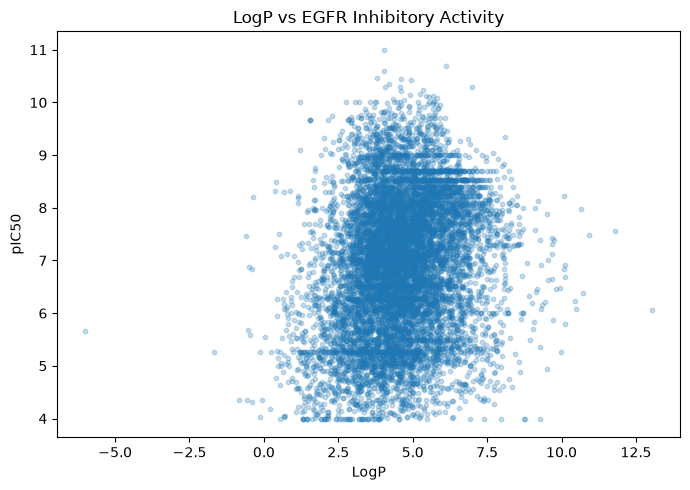

In [22]:
plt.figure(figsize=(7, 5))

plt.scatter(
    features_df["LogP"],
    features_df["pIC50"],
    alpha=0.25,
    s=10
)

plt.xlabel("LogP")
plt.ylabel("pIC50")
plt.title("LogP vs EGFR Inhibitory Activity")

plt.tight_layout()
plt.show()

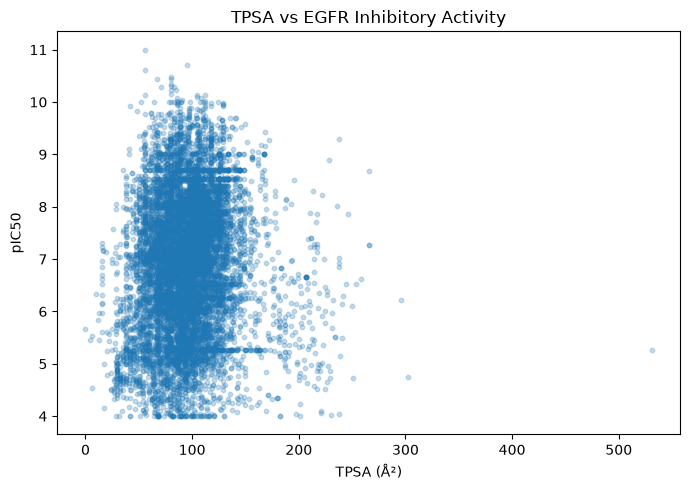

In [23]:
plt.figure(figsize=(7, 5))

plt.scatter(
    features_df["TPSA"],
    features_df["pIC50"],
    alpha=0.25,
    s=10
)

plt.xlabel("TPSA (Å²)")
plt.ylabel("pIC50")
plt.title("TPSA vs EGFR Inhibitory Activity")

plt.tight_layout()
plt.show()

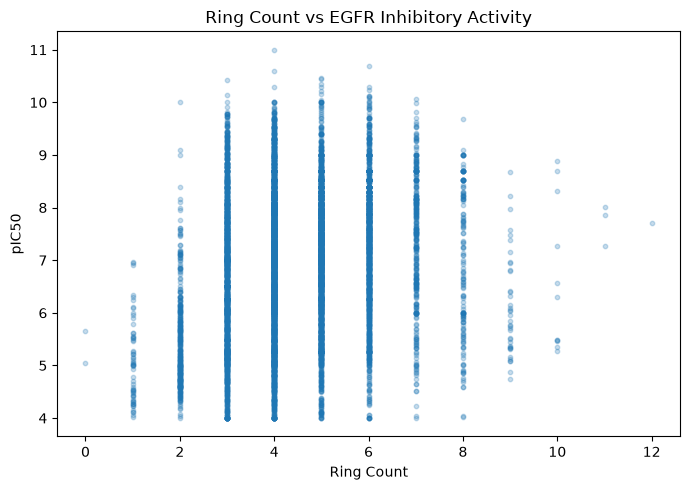

In [24]:
plt.figure(figsize=(7, 5))

plt.scatter(
    features_df["RingCount"],
    features_df["pIC50"],
    alpha=0.25,
    s=10
)

plt.xlabel("Ring Count")
plt.ylabel("pIC50")
plt.title("Ring Count vs EGFR Inhibitory Activity")

plt.tight_layout()
plt.show()

## Descriptor Correlations

Pearson correlations were calculated to evaluate relationships among molecular descriptors and EGFR inhibitory activity.

In [25]:
descriptor_cols = [
    "pIC50",
    "MolWt",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount",
    "HeavyAtomCount"
]

correlation_matrix = features_df[descriptor_cols].corr()

correlation_matrix.round(2)

,pIC50,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,RingCount,HeavyAtomCount
pIC50,1.00,0.24,0.20,0.09,0.18,0.26,0.18,0.22,0.23
MolWt,0.24,1.00,0.55,0.65,0.38,0.77,0.75,0.71,0.97
LogP,0.20,0.55,1.00,-0.06,0.10,0.17,0.35,0.48,0.52
TPSA,0.09,0.65,-0.06,1.00,0.59,0.79,0.59,0.37,0.67
HBD,0.18,0.38,0.10,0.59,1.00,0.40,0.33,0.19,0.37
HBA,0.26,0.77,0.17,0.79,0.40,1.00,0.68,0.52,0.78
RotatableBonds,0.18,0.75,0.35,0.59,0.33,0.68,1.00,0.31,0.76
RingCount,0.22,0.71,0.48,0.37,0.19,0.52,0.31,1.00,0.76
HeavyAtomCount,0.23,0.97,0.52,0.67,0.37,0.78,0.76,0.76,1.00


In [26]:
pic50_correlations = (
    correlation_matrix["pIC50"]
    .drop("pIC50")
    .sort_values(ascending=False)
)

pic50_correlations

HBA               0.258422
MolWt             0.243347
HeavyAtomCount    0.232474
RingCount         0.221966
LogP              0.201148
HBD               0.184981
RotatableBonds    0.184522
TPSA              0.090983
Name: pIC50, dtype: float64

### EDA Summary

Individual physicochemical descriptors showed weak positive linear
relationships with EGFR inhibitory activity. HBA had the strongest
correlation with pIC50 (r = 0.26), followed by molecular weight
(r = 0.24), heavy atom count (r = 0.23), ring count (r = 0.22),
and LogP (r = 0.20). TPSA showed the weakest relationship
(r = 0.09).

These results indicate that no individual physicochemical descriptor
is sufficient to explain EGFR inhibitory activity. Therefore,
subsequent QSAR modeling will combine molecular descriptors with
Morgan fingerprints to capture both general physicochemical
properties and molecular substructure information.

In [27]:
output_path = PROCESSED_DATA_DIR / "egfr_molecular_features.csv"

features_df.to_csv(output_path, index=False)

print("Saved molecular features to:")
print(output_path)
print("Dataset shape:", features_df.shape)

Saved molecular features to:
/Users/gracescanlan/Desktop/egfr-ml-drug-discovery/data/processed/egfr_molecular_features.csv
Dataset shape: (10381, 11)
